#Posicionamento Ponto Simples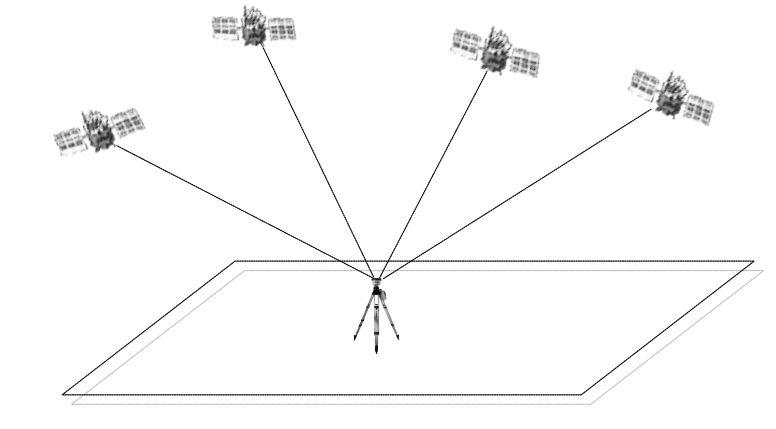

O posicionamento GNSS por ponto simples é modelado pela seguinte equação:

$PD= \sqrt{ (x_{rec}- x_{sat})^2 + (y_{rec}- y_{sat})^2 + (z_{rec}- z_{sat})^2} + c(dt_{rec}-dt^{sat})$

sendo: $x_{rec}$, $y_{rec}$ e $z_{rec}$ coordenadas do receptor; $x_{sat}$, $y_{sat}$ e $z_{sat}$ coordenadas do satélite; $\sqrt{ (x_{rec}- x_{sat})^2 + (y_{rec}- y_{sat})^2 + (z_{rec}- z_{sat})^2}$ a distância geométrica entre o receptor e o satélite; $dt_{rec}$ e $dt^{sat}$ os atrasos de relógio no receptor e no satétile; $PD$ a pseudodistância; e $c=299792458$ $m/s$ é a velocidade da luz no vácuo. Note que nesta formulação o posicionamento simples não leva em conta efeitos da ionosfera, troposfera e multicaminho, por exemplo.

1) No posicionamento de um receptor foram observadas 7 pseudodistâncias. A tabela a seguir apresenta a posição e atrasos do relógio dos respectivos satélites (obtidos das efemérides), e as PDs observadas. Calcular as coordenadas e o atraso do relógio do receptor.

Dados:

Coordenadas aproximadas do receptor:

$x_{{rec}_0}=3687627.3634$; $y_{{rec}_0}=-4620821.5137$; $z_{{rec}_0}=-2386884.4153$; $dt_{{rec}_0}=0.0$;

Matriz dos pesos: adotar a matriz identidade.

$x_{sat}(m)$ | $y_{sat}(m)$ | $z_{sat}(m)$ | $dt^{sat}(s)$ | $PD(m)$
---|---|---|---|---
13191926.036| -9634277.149| -20330138.156| -89.3963614364*10^(-6)|48100232.525
21244105.748| -15360752.012| -2877135.125| 570.3845890496*10^(-6)|47574517.142
-135122.979| -25794393.804| 5954578.737| 38.8125012807*10^(-6)|50223295.501
19720605.766| -17653994.853| -1657890.383| -47.6228094177*10^(-6)|47847868.400
25910284.743| 5823456.939| -2525126.594| 16.4975089736*10^(-6)|51708803.181
-1932297.136| -16733519.796| -20382553.367| 655.5761218187*10^(-6)|49370715.900
22374396.828| -3351761.100| -14280051.988| 26.9173316672*10^(-6)|49337431.587

Obs: para o ajustamento, normalmente se considera $(c*dt_{rec})$ como uma incognita, mesmo sabendo o valor de $c$, para evitar mal-condicionamento do sistema.




## Solução

In [1]:
# =========================
# Posicionamento GNSS por Ponto Simples (SPP) com Ajustamento por MQ
# - Incógnitas: X, Y, Z (ECEF) e b = c * dt_rec (em metros)
# - Modelo: PD_i + c*dt_sat_i = rho_i(X,Y,Z) + b + v_i
# - Pesos: Identidade (P = I)
# - Linearização e iteração até convergir
# =========================

import numpy as np  # Importa o NumPy para trabalhar com vetores/matrizes e álgebra linear

# -------------------------
# 1) Constantes físicas
# -------------------------
c = 299792458.0  # Velocidade da luz no vácuo (m/s)

# -------------------------
# 2) Dados do problema (7 satélites)
#    Cada linha: [Xsat, Ysat, Zsat] em metros (ECEF)
# -------------------------
sat_xyz = np.array([  # Cria uma matriz 7x3 com as coordenadas ECEF dos satélites
    [ 13191926.036,  -9634277.149, -20330138.156],  # Satélite 1
    [ 21244105.748, -15360752.012,  -2877135.125],  # Satélite 2
    [   -135122.979, -25794393.804,   5954578.737], # Satélite 3
    [ 19720605.766, -17653994.853,  -1657890.383],  # Satélite 4
    [ 25910284.743,   5823456.939,  -2525126.594],  # Satélite 5
    [ -1932297.136, -16733519.796, -20382553.367],  # Satélite 6
    [ 22374396.828,  -3351761.100, -14280051.988],  # Satélite 7
], dtype=float)  # Garante que tudo seja float

# -------------------------
# 3) Atraso de relógio dos satélites (dt_sat) em segundos
#    Os valores estão em microsegundos * 10^-6 (como na tabela)
# -------------------------
dt_sat = np.array([  # Cria um vetor 7x1 com dt_sat_i em segundos
    -89.3963614364e-6,   # Satélite 1
    570.3845890496e-6,   # Satélite 2
     38.8125012807e-6,   # Satélite 3
    -47.6228094177e-6,   # Satélite 4
     16.4975089736e-6,   # Satélite 5
    655.5761218187e-6,   # Satélite 6
     26.9173316672e-6,   # Satélite 7
], dtype=float)  # Garante tipo float

# -------------------------
# 4) Pseudodistâncias observadas (PD) em metros
# -------------------------
PD = np.array([  # Cria um vetor 7x1 com as PD observadas
    48100232.525,  # Satélite 1
    47574517.142,  # Satélite 2
    50223295.501,  # Satélite 3
    47847868.400,  # Satélite 4
    51708803.181,  # Satélite 5
    49370715.900,  # Satélite 6
    49337431.587,  # Satélite 7
], dtype=float)  # Garante tipo float

# -------------------------
# 5) Coordenadas aproximadas do receptor (chute inicial) em ECEF (m)
#    e dt_rec0 = 0 => b0 = c*dt_rec0 = 0 (m)
# -------------------------
X0 = 3687627.3634   # X aproximado do receptor (m)
Y0 = -4620821.5137  # Y aproximado do receptor (m)
Z0 = -2386884.4153  # Z aproximado do receptor (m)
b0 = 0.0            # b0 = c*dt_rec0 (m)


# -------------------------
# 7) Preparação do ajustamento
# -------------------------
P_star = PD + c * dt_sat  # Corrige as PD pelo relógio do satélite: P* = PD + c*dt_sat (m)

max_iter = 20  # Define um número máximo de iterações para segurança
tol = 1e-4     # Define tolerância para convergência (m) no incremento espacial

# -------------------------
# 8) Loop iterativo de MQ (Gauss-Newton)
# -------------------------
X = X0  # Inicializa X com o chute inicial
Y = Y0  # Inicializa Y com o chute inicial
Z = Z0  # Inicializa Z com o chute inicial
b = b0  # Inicializa b com o chute inicial

for it in range(1, max_iter + 1):  # Inicia iterações de 1 até max_iter
    dx = X - sat_xyz[:, 0]  # Vetor 7x1: diferença X_rec - X_sat para cada satélite
    dy = Y - sat_xyz[:, 1]  # Vetor 7x1: diferença Y_rec - Y_sat para cada satélite
    dz = Z - sat_xyz[:, 2]  # Vetor 7x1: diferença Z_rec - Z_sat para cada satélite

    rho = np.sqrt(dx*dx + dy*dy + dz*dz)  # Distância geométrica rho_i no chute atual (m)

    # Monta a matriz A (7x4) com derivadas parciais e coluna do viés b (coeficiente 1)
    A = np.zeros((7, 4), dtype=float)  # Cria matriz A vazia 7x4
    A[:, 0] = dx / rho                 # d(rho)/dX = (X - Xsat)/rho
    A[:, 1] = dy / rho                 # d(rho)/dY = (Y - Ysat)/rho
    A[:, 2] = dz / rho                 # d(rho)/dZ = (Z - Zsat)/rho
    A[:, 3] = 1.0                      # d(rho+b)/db = 1

    # Monta o vetor de fechamento w = P* - (rho + b)
    w = P_star - (rho + b)  # Vetor 7x1 (m)

    # Pesos identidade: P = I => N = A^T A e u = A^T w
    N = A.T @ A  # Matriz normal 4x4
    u = A.T @ w  # Vetor 4x1

    # Resolve o sistema normal: N * delta = u
    delta = np.linalg.solve(N, u)  # Resolve exatamente (4 incógnitas)

    # Separa incrementos
    dX = delta[0]  # Incremento em X (m)
    dY = delta[1]  # Incremento em Y (m)
    dZ = delta[2]  # Incremento em Z (m)
    db = delta[3]  # Incremento em b (m)

    # Atualiza estimativas
    X = X + dX  # Atualiza X
    Y = Y + dY  # Atualiza Y
    Z = Z + dZ  # Atualiza Z
    b = b + db  # Atualiza b

    # Critério de convergência baseado no incremento espacial
    step_norm = np.sqrt(dX*dX + dY*dY + dZ*dZ)  # Norma do passo (m)

    print(f"Iteração {it:02d} | dX={dX:+.6f} m  dY={dY:+.6f} m  dZ={dZ:+.6f} m  db={db:+.6f} m | ||dXYZ||={step_norm:.6e} m")  # Mostra evolução

    if step_norm < tol:  # Verifica se convergiu
        break  # Sai do loop se convergiu

# -------------------------
# 9) Pós-ajustamento: resíduos, sigma0, covariância
# -------------------------
dx = X - sat_xyz[:, 0]  # Recalcula dx final
dy = Y - sat_xyz[:, 1]  # Recalcula dy final
dz = Z - sat_xyz[:, 2]  # Recalcula dz final
rho = np.sqrt(dx*dx + dy*dy + dz*dz)  # Recalcula rho final

v = P_star - (rho + b)  # Resíduos v_i (m), já no modelo final

n = 7          # Número de observações (7 pseudodistâncias)
u_unknowns = 4 # Número de incógnitas (X,Y,Z,b)
nu = n - u_unknowns  # Graus de liberdade

sigma0_sq = (v @ v) / nu  # Variância a posteriori (como P=I)
sigma0 = np.sqrt(sigma0_sq)  # Desvio-padrão a posteriori

# Reconstroi A final para covariância (opcional, mas útil)
A = np.zeros((7, 4), dtype=float)  # Cria A final
A[:, 0] = dx / rho                 # Derivada em X
A[:, 1] = dy / rho                 # Derivada em Y
A[:, 2] = dz / rho                 # Derivada em Z
A[:, 3] = 1.0                      # Derivada em b

N = A.T @ A  # Normais finais
Qxx = np.linalg.inv(N)  # Matriz de cofatores (A^T A)^-1
Cxx = sigma0_sq * Qxx   # Covariância estimada das incógnitas

# -------------------------
# 10) Relógio do receptor (dt_rec) a partir de b = c*dt_rec
# -------------------------
dt_rec = b / c  # Converte viés em metros para segundos

# -------------------------
# 11) Impressão dos resultados finais
# -------------------------
print("\n================ RESULTADO FINAL (ECEF) ================")  # Cabeçalho
print(f"X = {X:.4f} m")  # X final
print(f"Y = {Y:.4f} m")  # Y final
print(f"Z = {Z:.4f} m")  # Z final

print("\n================ RELÓGIO DO RECEPTOR ================")  # Cabeçalho
print(f"b = c*dt_rec = {b:.4f} m")  # Viés em metros
print(f"dt_rec = {dt_rec:.12f} s")  # Relógio em segundos
print(f"dt_rec = {dt_rec*1e6:.3f} microsegundos")  # Relógio em microsegundos

print("\n================ RESÍDUOS (m) ================")  # Cabeçalho
for i, vi in enumerate(v, start=1):  # Itera sobre resíduos com índice começando em 1
    print(f"Sat {i}: v = {vi:+.3f} m")  # Imprime resíduo do satélite i

print("\n================ QUALIDADE ================")  # Cabeçalho
print(f"Graus de liberdade (nu) = {nu}")  # Mostra nu
print(f"sigma0 = {sigma0:.4f} m")  # Mostra sigma0

print("\n================ PRECISÕES (1-sigma) DAS INCÓGNITAS ================")  # Cabeçalho
std_X = np.sqrt(Cxx[0, 0])  # Desvio-padrão de X (m)
std_Y = np.sqrt(Cxx[1, 1])  # Desvio-padrão de Y (m)
std_Z = np.sqrt(Cxx[2, 2])  # Desvio-padrão de Z (m)
std_b = np.sqrt(Cxx[3, 3])  # Desvio-padrão de b (m)
print(f"std(X) = {std_X:.4f} m")  # Imprime precisão de X
print(f"std(Y) = {std_Y:.4f} m")  # Imprime precisão de Y
print(f"std(Z) = {std_Z:.4f} m")  # Imprime precisão de Z
print(f"std(b) = {std_b:.4f} m  -> std(dt_rec) = {(std_b/c):.12e} s")  # Imprime precisão de b e dt


Iteração 01 | dX=-26.370947 m  dY=-35.089071 m  dZ=-23.313391 m  db=+27158701.916469 m | ||dXYZ||=4.970094e+01 m
Iteração 02 | dX=+0.000053 m  dY=-0.000050 m  dZ=-0.000018 m  db=+0.000006 m | ||dXYZ||=7.560367e-05 m

================ RESULTADO FINAL (ECEF) ================
X = 3687600.9925 m
Y = -4620856.6028 m
Z = -2386907.7287 m

================ RELÓGIO DO RECEPTOR ================
b = c*dt_rec = 27158701.9165 m
dt_rec = 0.090591678315 s
dt_rec = 90591.678 microsegundos

================ RESÍDUOS (m) ================
Sat 1: v = -3.746 m
Sat 2: v = +7.335 m
Sat 3: v = +1.411 m
Sat 4: v = -8.323 m
Sat 5: v = -2.548 m
Sat 6: v = +0.461 m
Sat 7: v = +5.411 m

================ QUALIDADE ================
Graus de liberdade (nu) = 3
sigma0 = 7.6392 m

================ PRECISÕES (1-sigma) DAS INCÓGNITAS ================
std(X) = 8.6458 m
std(Y) = 9.7436 m
std(Z) = 7.5528 m
std(b) = 8.5163 m  -> std(dt_rec) = 2.840718583659e-08 s
